<a href="https://colab.research.google.com/github/aayushmanz/Python-For-Data-Science/blob/main/Pandas%20in%20Python/Practice%20in%20pandas/Practice_6_Dirty_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/workspaces/Python-For-Data-Science/Database from Kaggle/dirty_cafe_sales.csv')


In [2]:
df.shape # the size of the index are 10000 followed by 8 columns

(10000, 8)

In [3]:
df['Item'].hasnans # ok in our dataset there are several NaN values in our items columns

True

In [4]:
df[df['Item'].isnull()].count() # now we counted all values which are null in database.

Transaction ID      333
Item                  0
Quantity            330
Price Per Unit      326
Total Spent         329
Payment Method      251
Location            229
Transaction Date    327
dtype: int64

In [5]:
df[df['Item'].notnull()].count()


Transaction ID      9667
Item                9667
Quantity            9532
Price Per Unit      9495
Total Spent         9498
Payment Method      7170
Location            6506
Transaction Date    9514
dtype: int64

In [6]:
df.shape # sorry woh experiment toh khoob mare but fr socha sab NaN uda deta hu kya hi hoga

(10000, 8)

In [7]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [8]:
bringmeback = {
    1.0 : "Cookie",
    2.0 : "Coffee",
    3.0 : "Cake",
    4.0 : "Smoothie",
    5.0 : "Salad"
}
df['Price Per Unit'] = df['Price Per Unit'].replace(['ERROR', 'UNKNOWN', 'NaN'], np.nan)
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'])
df['Item'] = df['Item'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(bringmeback))
df.dropna(subset=['Item'], inplace=True)

df.shape # so this is our cleaned data

(9836, 8)

In [9]:
df.head(50)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,Cake,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,Cake,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [10]:
# lets check that how many number of NaN and ERROR values in Quantity
df[df['Quantity']=='ERROR']

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
20,TXN_3522028,Smoothie,ERROR,4.0,20.0,Cash,In-store,2023-04-04
55,TXN_5522862,Cookie,ERROR,1.0,2.0,Credit Card,Takeaway,2023-03-19
117,TXN_2148617,Juice,ERROR,3.0,9.0,Digital Wallet,UNKNOWN,2023-01-10
177,TXN_1896955,Salad,ERROR,5.0,25.0,NaN,In-store,2023-09-23
178,TXN_5075974,Smoothie,ERROR,4.0,16.0,Digital Wallet,NaN,2023-04-11
...,...,...,...,...,...,...,...,...
9832,TXN_3325234,Tea,ERROR,1.5,1.5,ERROR,In-store,2023-08-26
9846,TXN_7621213,Coffee,ERROR,2.0,6.0,NaN,In-store,2023-03-07
9911,TXN_2464054,Coffee,ERROR,2.0,10.0,NaN,Takeaway,2023-08-18
9935,TXN_9778251,Tea,ERROR,1.5,6.0,NaN,Takeaway,2023-11-09


In [11]:
# now its time to calculate and resolve the issues of these three numerical columns

# we converted all error and unknown values into NaN
df['Quantity'] = df['Quantity'].replace(['ERROR', 'UNKNOWN'], np.nan) 
df['Total Spent'] = df['Total Spent'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Price Per Unit'] = df['Price Per Unit'].replace(['ERROR', 'UNKNOWN'], np.nan)


# Then we also convert all values into numeric for solutions
mycols = ['Total Spent','Quantity']
for i in mycols:
  df[i] = pd.to_numeric(df[i], errors='coerce')



df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
df['Total Spent'] = df['Total Spent'].fillna(df['Price Per Unit'] * df['Quantity'])

df.dropna(subset='Price Per Unit', inplace=True) # i use it because there are some NaN values which are not deleted !
df.dropna(subset='Total Spent', inplace=True)

df.head(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,Cake,3.0,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,Cake,5.0,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31


In [12]:
# now its time to set the payment method colum
# there are lots of NaN values and some values are UNKNOWN or ERROR
# so I decided that i don't want to delete these NaN values so i m gonna replace them with cash
# because cash  is the most common way of transaction

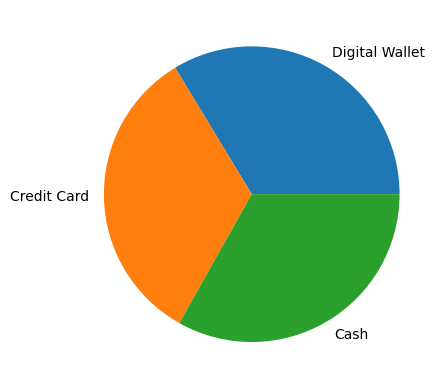

In [13]:
# I just want to see that is cash is really common or not.
# in this chart all type of transaction methods are common.

a = df['Payment Method'].replace(['UNKNOWN','ERROR'], np.nan)
a.value_counts().plot(kind='pie')
plt.show()


In [14]:
df['Payment Method'] = df['Payment Method'].replace(['UNKNOWN','ERROR'], np.nan)
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,Smoothie,4.0,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [15]:
# in this code i randomly push those three possible transaction methods in our dataset.

mix = ['Credit Card','Cash','Digital Wallet']

df.loc[df['Payment Method'].isna(), 'Payment Method']= np.random.choice(mix, size=df['Payment Method'].isna().sum())
df.head(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Cash,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,Cake,3.0,3.0,9.0,Credit Card,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,Cake,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Credit Card,In-store,2023-12-31


<Axes: >

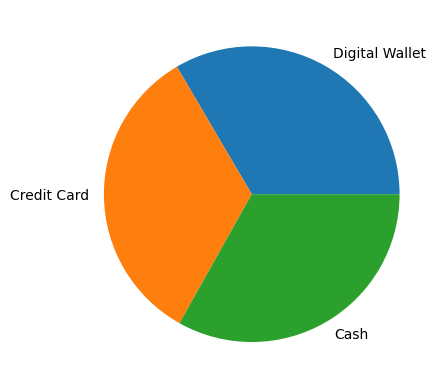

In [16]:
df['Payment Method'].value_counts().plot(kind='pie') # ok distribution is same as original.

In [17]:
df['Location'] = df['Location'].replace(['UNKNOWN','ERROR'], np.nan)

df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Cash,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,Smoothie,4.0,4.0,16.0,Credit Card,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Cash,NaN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


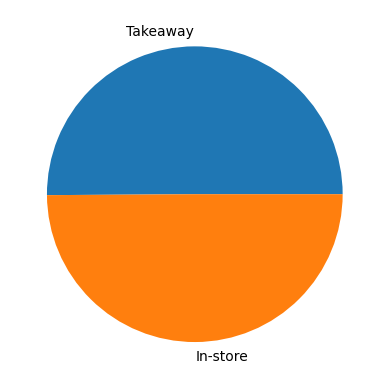

In [18]:
df['Location'].value_counts().plot(kind='pie')
plt.show()

In [19]:
mix = ['Takeaway','In-Store']
df.loc[df['Location'].isna(), 'Location']=np.random.choice(mix, size=df['Location'].isna().sum())

df.sample(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1886,TXN_1005331,Coffee,1.0,2.0,2.0,Digital Wallet,Takeaway,2023-11-04
8188,TXN_1992699,Cookie,2.0,1.0,2.0,Credit Card,Takeaway,2023-05-08
2461,TXN_8031804,Coffee,4.0,2.0,8.0,Credit Card,Takeaway,2023-07-01
4690,TXN_1907428,Juice,4.0,3.0,12.0,Credit Card,In-store,2023-06-06
3298,TXN_1244509,Smoothie,3.0,4.0,12.0,Credit Card,In-store,2023-02-21
6176,TXN_2672126,Cookie,3.0,1.0,3.0,Cash,Takeaway,2023-07-07
3785,TXN_5799196,Sandwich,3.0,4.0,12.0,Digital Wallet,In-Store,2023-12-03
7347,TXN_7961171,Juice,3.0,3.0,9.0,Cash,In-store,2023-01-27
6672,TXN_9365766,Cake,4.0,3.0,12.0,Digital Wallet,In-store,2023-02-13
7211,TXN_2639283,Juice,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-08-13


In [20]:
# I just use ffill() method because in Transaction Date column have lots of NaN (null) values.
# so because of ffill() can replace the null value with upper date in index. 

df['Transaction Date']= df['Transaction Date'].replace(['UNKNOWN', 'ERROR'], np.nan)
df['Transaction Date'] = df['Transaction Date'].ffill()
df['Transaction Date']= pd.to_datetime(df['Transaction Date'], errors='coerce')
df.dropna(subset='Transaction Date', inplace=True) # for more clean data
df.sample(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
3116,TXN_9703331,Cake,2.0,3.0,6.0,Cash,In-Store,2023-09-09
3294,TXN_5222110,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-01-30
6395,TXN_5963749,Cake,1.0,3.0,3.0,Digital Wallet,In-store,2023-11-04
2274,TXN_7640700,Juice,2.0,3.0,6.0,Digital Wallet,In-Store,2023-01-15
8498,TXN_6110108,Tea,5.0,1.5,7.5,Credit Card,Takeaway,2023-02-10
4427,TXN_2103626,Juice,3.0,3.0,9.0,Cash,In-store,2023-04-23
2989,TXN_9429128,Coffee,4.0,2.0,8.0,Credit Card,In-store,2023-12-19
904,TXN_2820693,Salad,3.0,5.0,15.0,Cash,Takeaway,2023-05-05
7587,TXN_3827851,Coffee,1.0,2.0,2.0,Credit Card,Takeaway,2023-01-09
545,TXN_4621665,Smoothie,5.0,4.0,20.0,Credit Card,Takeaway,2023-01-17


In [21]:
df.info() # ok every thing is ok in dtype.

<class 'pandas.DataFrame'>
Index: 9784 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9784 non-null   str           
 1   Item              9784 non-null   str           
 2   Quantity          9784 non-null   float64       
 3   Price Per Unit    9784 non-null   float64       
 4   Total Spent       9784 non-null   float64       
 5   Payment Method    9784 non-null   str           
 6   Location          9784 non-null   str           
 7   Transaction Date  9784 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 687.9 KB


In [22]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9784.000000,9784.000000,9784.000000,9784
mean,3.025859,2.964789,8.983034,2023-07-02 02:12:45.331153
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.421943,1.278428,6.017761,NaN


In [23]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [24]:
df.to_csv('Cleaned_Dirty_cafe_sales.csv')   # for download new clean data !

### EDA :

### Item :

**Conclusions :**

In [32]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Cash,In-Store,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [34]:
df['Item'].describe()

count     9784
unique       8
top       Cake
freq      1368
Name: Item, dtype: object

<Axes: >

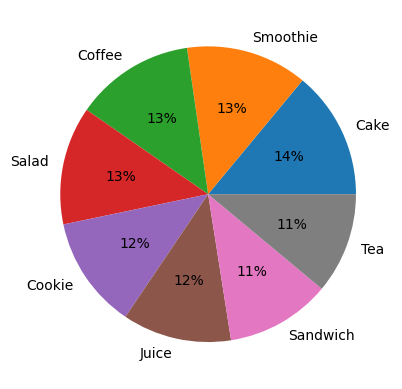

In [39]:
df['Item'].value_counts().plot(kind='pie', autopct='%0.0f%%')

<Axes: xlabel='Item'>

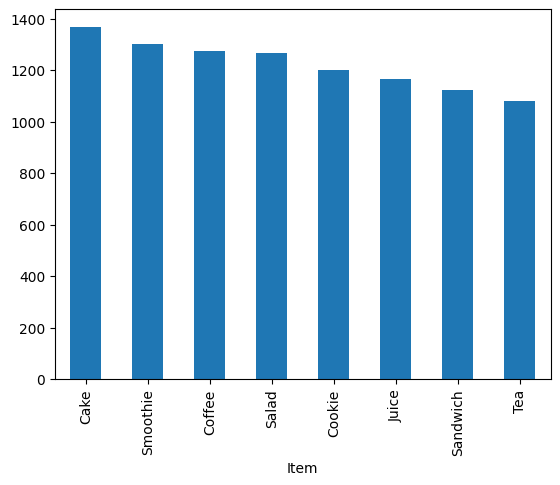

In [40]:
df['Item'].value_counts().plot(kind='bar')

In [43]:
df['Item'].isnull().sum()/len(df['Item'])

np.float64(0.0)